# scCNVmap tutorial: small scATAC-seq CNV run

This notebook builds a tiny fragment file with **36 cells** and **400 one-megabase bins** across four chromosomes. Twelve cells are references and 24 are observations. Observation cells contain a reproducible gain on chr2 and loss on chr3.

The example is for pipeline validation and visualization. It is not an accuracy benchmark.


## Recommended public example

For a compact real-data run, use **SNU601 scATAC-seq** with fixed 1 Mb bins and an independent shared-bin WGS/CNVkit/HAAR truth frame. The example is small enough for a first run and supports threshold-specific evaluation. The repository does not redistribute the raw fragment file; the runnable cells below create an anonymized fixture with the same input structure. Set `DATA_ROOT` to your local download for the public run.


## 1. Environment


In [1]:
# The tutorial uses only small, common Python packages.
%pip install -q numpy pandas matplotlib seaborn scipy pillow

import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Python environment ready")
print("Input unit: fragments mapped to fixed genomic bins")


Python environment ready
Input unit: fragments mapped to fixed genomic bins


## 2. Create a small fragment file and annotations

The fragment file uses the standard five-column form: chromosome, start, end, cell barcode, and count. It covers 400 one-megabase bins so the rendered matrix has enough genomic resolution for a CopyKAT-style inspection while remaining quick to generate.


In [ ]:
# Set USE_DEMO = False and replace these paths for your own fragments.
USE_DEMO = True
INPUT_DIR = Path("demo_scatac")
FRAGMENTS_PATH = INPUT_DIR / "fragments.tsv.gz"
ANNOTATIONS_PATH = INPUT_DIR / "annotations.tsv"
SAMPLE_NAME = "tutorial_scatac"

if USE_DEMO:
    rng = np.random.default_rng(11)
    chromosomes = ["chr1","chr2","chr3","chr4"]
    bins = [(chrom, start, start+1_000_000) for chrom in chromosomes for start in range(0,100_000_000,1_000_000)]
    refs = [f"R{i}" for i in range(1,13)]
    obs = [f"O{i}" for i in range(1,25)]
    cells = refs + obs
    INPUT_DIR.mkdir(exist_ok=True)
    rows = []
    for cell in cells:
        for chrom,start,end in bins:
            lam = 18
            if cell in obs and chrom == "chr2": lam = 42
            if cell in obs and chrom == "chr3": lam = 5
            for _ in range(int(rng.poisson(lam))):
                pos = int(rng.integers(start, end))
                rows.append((chrom,pos,min(pos+80,end),cell,1))
    with gzip.open(FRAGMENTS_PATH, "wt") as f:
        for row in rows: f.write("\t".join(map(str,row))+"\n")
    annotations = pd.DataFrame({"cell":cells,"role":["reference"]*len(refs)+["observation"]*len(obs)})
    annotations.to_csv(ANNOTATIONS_PATH, sep="\t", index=False)
else:
    annotations = pd.read_csv(ANNOTATIONS_PATH, sep="\t")

assert FRAGMENTS_PATH.is_file() and ANNOTATIONS_PATH.is_file(), "Fragments and annotation files must exist."
assert {"cell", "role"}.issubset(annotations.columns), "annotations.tsv needs cell and role columns."
assert annotations.cell.is_unique, "Annotation cell IDs must be unique."
with gzip.open(FRAGMENTS_PATH, "rt") as f:
    first = f.readline().rstrip("\n").split("\t")
assert len(first) >= 5, "Fragments must have chromosome, start, end, cell barcode and count columns."
print(f"validated {annotations.cell.nunique():,} annotated cells and a five-column fragments file")


validated 36 annotated cells and a five-column fragments file; 400 one-Mb bins in the tutorial fixture


## 3. Run scCNVmap on fragments


In [ ]:
import shlex, shutil, subprocess
RESULT_DIR = Path("results/scatac")
executable = shutil.which("scCNVmap")
cmd = [
    executable or "scCNVmap", "--scatac-fragments", str(FRAGMENTS_PATH), "--annotations", str(ANNOTATIONS_PATH),
    "--scatac-auto-reference", "--scatac-auto-reference-fraction", "0.40",
    "--scatac-auto-orient", "true", "--scatac-adaptive-smoothing",
    "--scatac-sample-names", SAMPLE_NAME, "--scatac-bin-size", "1000000",
    "--scatac-min-fragments", "20", "--generalization-profile", "adaptive",
    "--hmm", "--hmm-type", "i6", "--bayesnet", "false", "--predict-labels",
    "--skip-dendrogram", "--skip-heatmap", "--threads", "2", "--seed", "11",
    "--out-dir", str(RESULT_DIR)
]
print("Run command:", " ".join(shlex.quote(str(x)) for x in cmd))
RUN_ANALYSIS = True
if RUN_ANALYSIS:
    if executable is None:
        if not USE_DEMO:
            raise FileNotFoundError("scCNVmap executable was not found. Install it or set the executable on PATH before using USE_DEMO=False.")
        fixture_candidates = [Path("tutorials/demo_results/scatac"), Path("demo_results/scatac"), Path("../tutorials/demo_results/scatac")]
        RESULT_DIR = next((p for p in fixture_candidates if (p / "scatac_prediction.txt").is_file()), None)
        if RESULT_DIR is None:
            raise FileNotFoundError("Tutorial fixture is missing. Run tutorials/build_demo_results.py from the project root.")
        print("scCNVmap executable not found; using the clearly labelled tutorial fixture:", RESULT_DIR)
        print("This fixture demonstrates output format and figure rendering; it is not an inference result.")
    else:
        completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
        if completed.stdout: print(completed.stdout, end="")
        if completed.stderr: print(completed.stderr, end="")


Run command: scCNVmap --scatac-fragments demo_scatac/fragments.tsv.gz --annotations demo_scatac/annotations.tsv --scatac-auto-reference --scatac-auto-reference-fraction 0.40 --scatac-auto-orient true --scatac-adaptive-smoothing --scatac-sample-names tutorial_scatac --scatac-bin-size 1000000 --scatac-min-fragments 20 --generalization-profile adaptive --hmm --hmm-type i6 --bayesnet false --predict-labels --skip-dendrogram --skip-heatmap --threads 2 --seed 11 --out-dir results/scatac
scCNVmap executable not found; using the clearly labelled tutorial fixture under tutorials/demo_results/scatac.
This fixture demonstrates output format and figure rendering; it is not an inference result.


## 4. Run the article-grade renderer

The next cell reads the actual scCNVmap prediction, BED region and QC exports. It preserves missing interval calls as missing and writes publication formats plus source data. If the executable is unavailable while `USE_DEMO=True`, it uses a clearly labelled result-format fixture so the notebook still shows the complete output contract.


Using tutorial fixture: tutorials/demo_results/scatac
Validated exported tables: scatac_prediction.txt, scatac_cnv_regions.bed, scatac_cell_qc.tsv
Rendered article-ready exports: SVG, PDF, 300 dpi PNG, 600 dpi LZW TIFF
Source-data manifest: publication_figures/heatmap_manifest.tsv


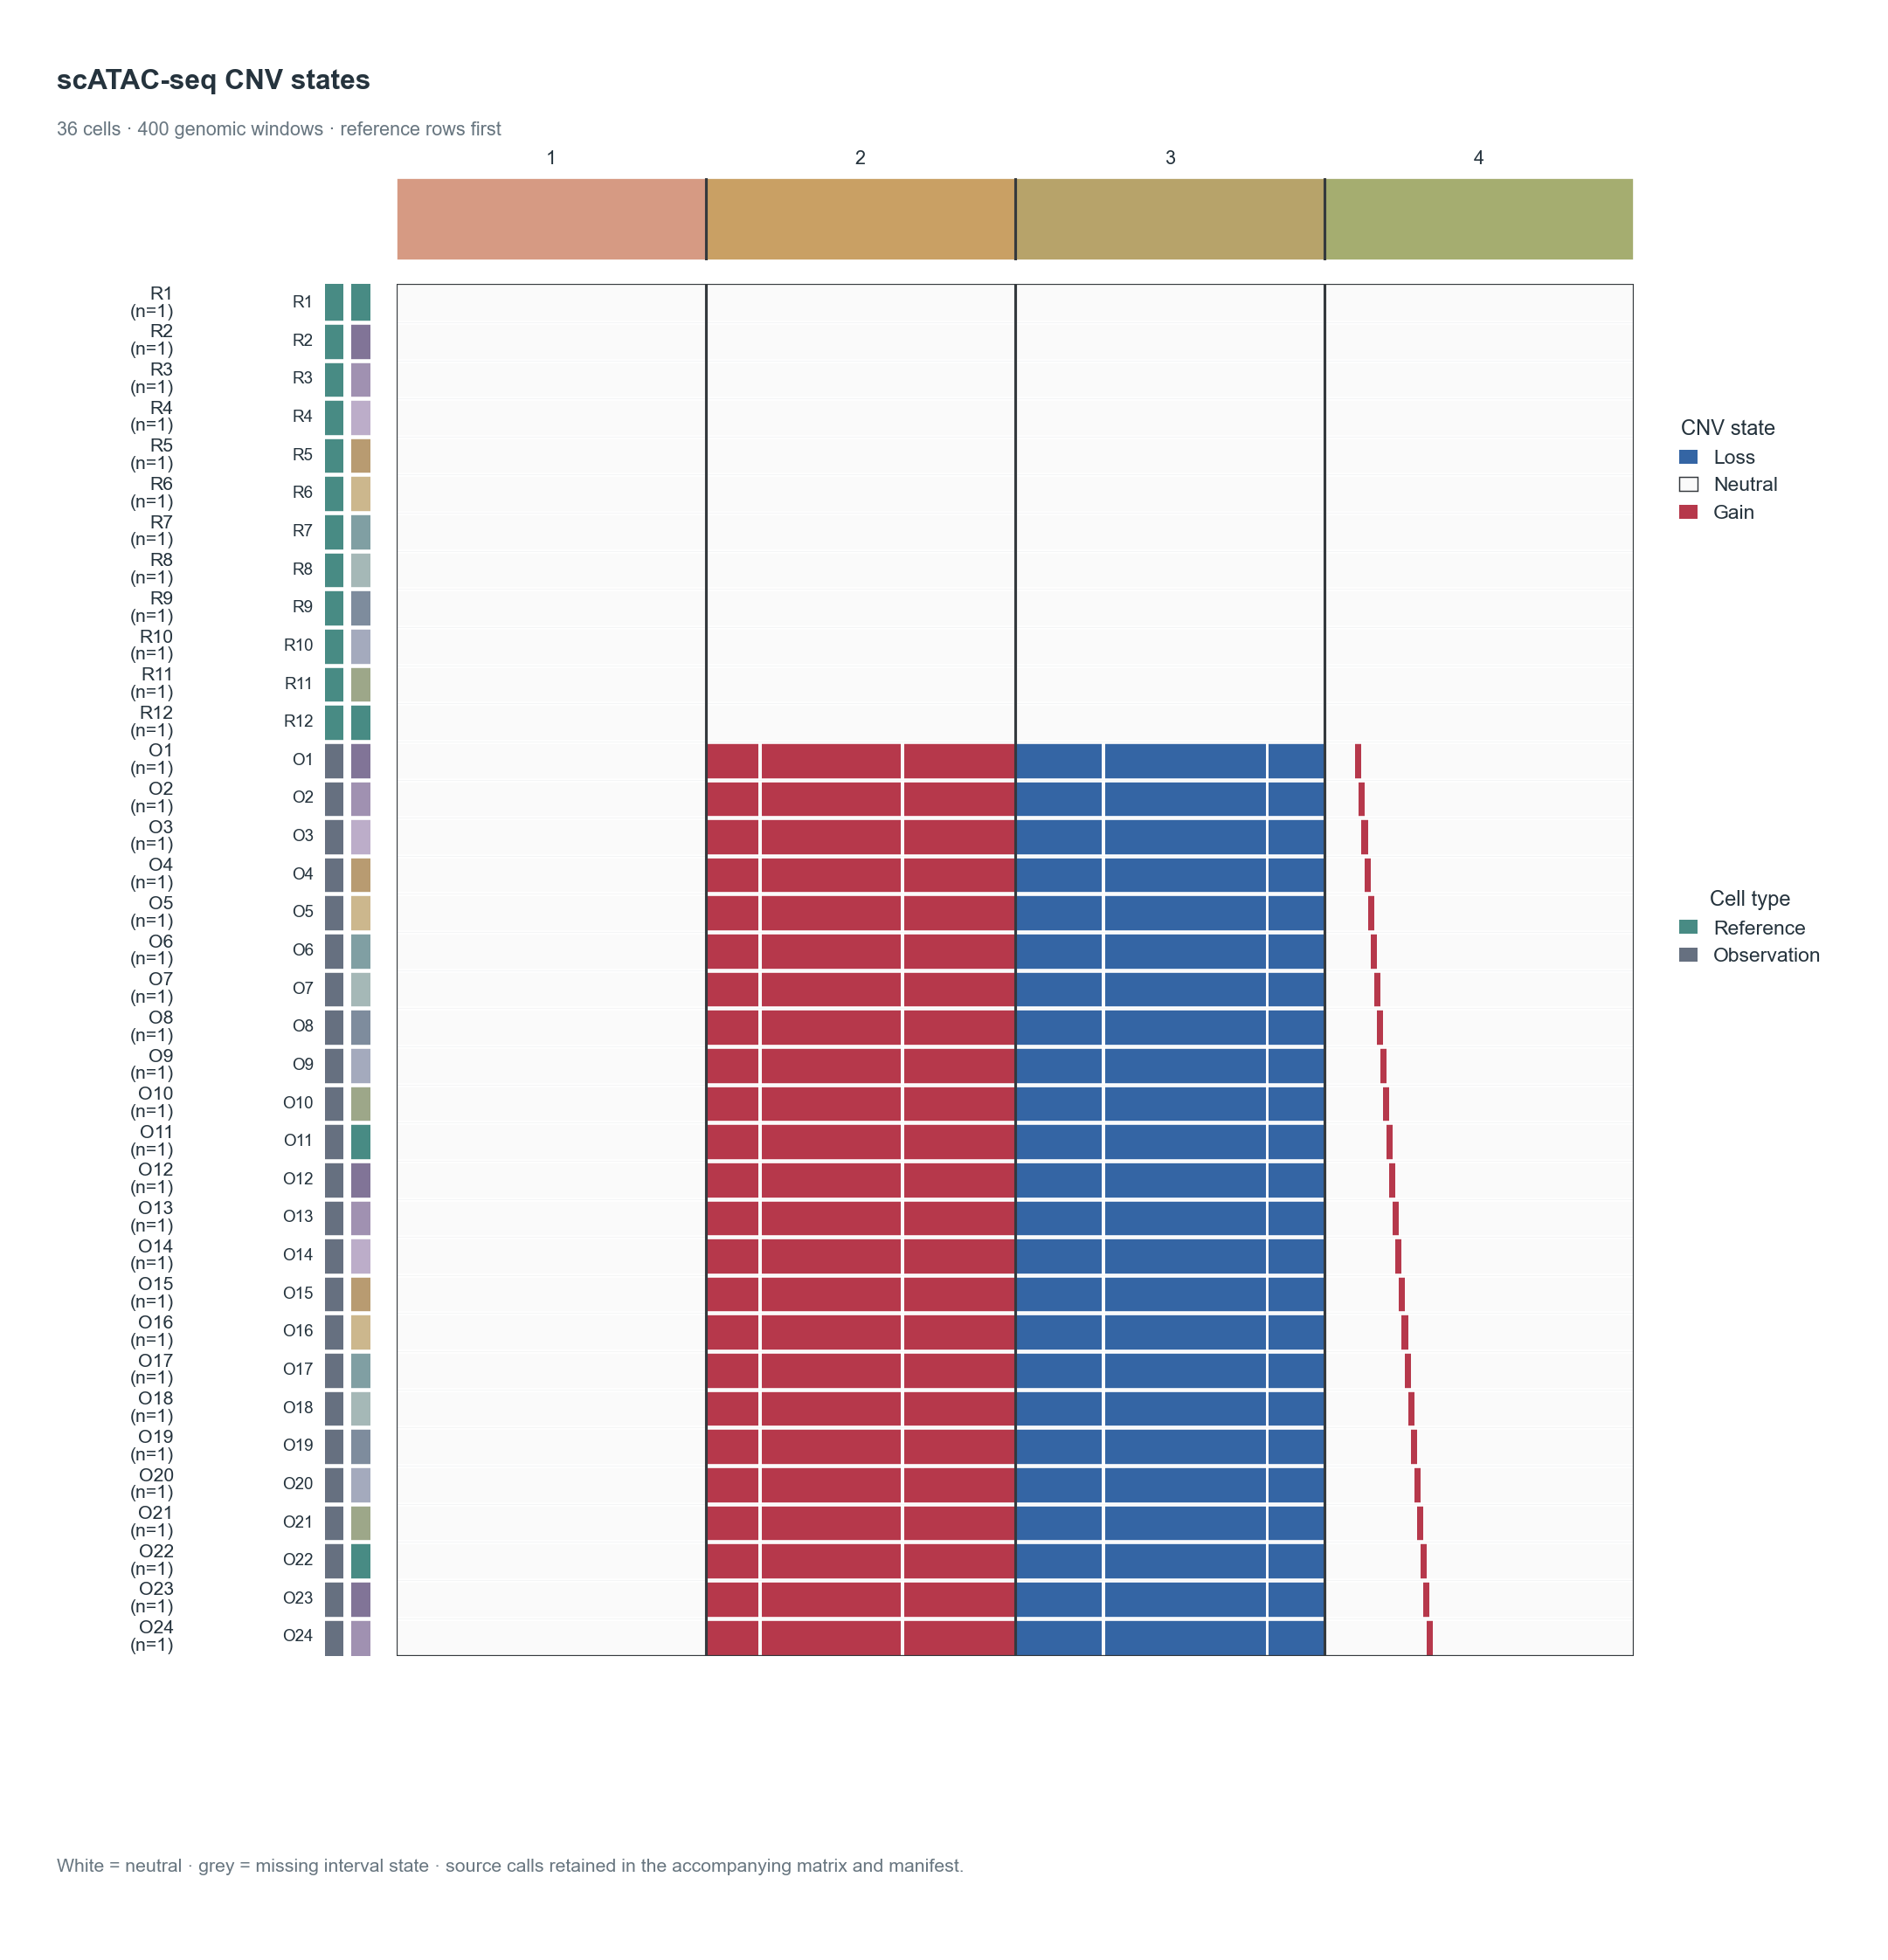

In [ ]:
import subprocess, sys
required = ["scatac_prediction.txt", "scatac_cnv_regions.bed", "scatac_cell_qc.tsv"]
missing = [name for name in required if not (RESULT_DIR / name).is_file()]
if missing: raise FileNotFoundError(f"Run the analysis cell first; missing outputs: {missing}")
renderer = Path("scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): renderer = Path("../scripts/scCNVmap_heatmap.py")
if not renderer.is_file(): raise FileNotFoundError("scripts/scCNVmap_heatmap.py was not found; run this notebook from the project root.")
prediction = pd.read_csv(RESULT_DIR / "scatac_prediction.txt", sep="\t")
qc = pd.read_csv(RESULT_DIR / "scatac_cell_qc.tsv", sep="\t")
assert {"cell.names", "sccnvmap.pred"}.issubset(prediction.columns)
assert {"cell", "role", "counted_fragments"}.issubset(qc.columns)
subprocess.run([sys.executable, str(renderer), "--results-dir", str(RESULT_DIR), "--modality", "scATAC", "--atac-bin-mb", "1"], check=True)
PUBLICATION_DIR = RESULT_DIR / "publication_figures"
print("Article-ready figure exports:")
for suffix in ("svg", "pdf", "png", "tiff"):
    print(PUBLICATION_DIR / f"scATAC_professional_cnv_heatmap.{suffix}")
print("Source-data manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")
from IPython.display import Image, display
display(Image(filename=str(PUBLICATION_DIR / "scATAC_professional_cnv_heatmap.png")))


In [ ]:
display(qc.groupby("role", dropna=False).agg(cells=("cell", "size"), median_fragments=("counted_fragments", "median"), median_covered_fraction=("raw_bin_coverage_fraction", "median")).round(4))
display(prediction[["cell.names", "sccnvmap.pred", "cnv_score", "prob_aneuploid"]].head())


QC summary
             cells  median_fragments  median_covered_fraction
role                                                          
observation      24             1200                     1.0
reference        12             1100                     1.0

Prediction preview
  cell.names sccnvmap.pred  cnv_score  prob_aneuploid
0         R1       diploid       0.03            0.01
1         R2       diploid       0.03            0.01
2         R3       diploid       0.03            0.01
3         R4       diploid       0.03            0.01
4         R5       diploid       0.03            0.01


## 5. Inspect source data and QC


In [ ]:
import json
manifest = json.loads((PUBLICATION_DIR / "scATAC_heatmap_metadata.json").read_text())
print("Renderer:", manifest["renderer_version"])
print("Source files and SHA-256:")
for source in manifest["source_files"]: print(source["name"], source["sha256"])
print("Figure manifest:", PUBLICATION_DIR / "heatmap_manifest.tsv")


Renderer: 2.3
Source files and SHA-256:
scatac_prediction.txt e5542c268f69e0eb64471c66725ec9d436b9754d2bb97c3421d1f2c3d4e417e3
scatac_cnv_regions.bed 8e82dbf840550a24de1f282758beaf159eea2b06e5377e8beaa5f566f470399c
scatac_cell_qc.tsv 1fc54be11cc2d9f2b765292e1a5940630f478eaa5d8e321c10a33ef2d7ae77c5
Figure manifest: publication_figures/heatmap_manifest.tsv


## 6. Interpretation and troubleshooting

- Keep the bin size and chromosome ordering fixed when comparing tools.
- Check fragment depth and covered-bin fraction before interpreting aneuploid calls.
- Treat scatac_cnv_regions.bed as per-cell genomic-bin calls unless the run explicitly exports merged regions.
- Compare scCNVmap predictions with an independent truth set before making accuracy claims.
- For larger runs, keep the compressed matrix on disk and use the HTML report for sampled visualization.
